# Persistent Homology Forecasting

This notebook runs and inspects the first persistent-homology forecasting benchmark on the active-set family-state representation. It uses the same supervised rows, chronological folds, and downstream logistic regression setup as the successful family-level PCA benchmark.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, display, Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PROCESSED = ROOT / "data" / "processed"
FIGURES = PROCESSED / "figures" / "tda"

## Run Benchmark

The full run computes H0/H1 persistence summaries for 24h, 72h, and 168h sliding windows. It may take several minutes because it computes persistence for each chronological fold without leakage.

In [2]:
from persistent_homology_forecasting import run_all

RUN_FULL = False

if RUN_FULL:
    run_all(
        PROCESSED / "candidate_universe_markets.parquet",
        PROCESSED / "prices_long.parquet",
        PROCESSED / "universe_b_macro_crypto_panel.parquet",
        PROCESSED,
        windows=(24, 72, 168),
    )

/Users/aaditjerfy/Documents/Playground/Topology-of-Prediction-Market-Belief-Dynamics/polymarket_topology/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Saved Summary

In [3]:
summary_path = PROCESSED / "tda_summary.md"
display(Markdown(summary_path.read_text()))

TDA FORECASTING SUMMARY

1. Dataset
- number of markets: 171
- number of timestamps: 14,464
- number of supervised rows: 532,979
- YES rate by unique market: 0.111

2. Baselines
- market probability Brier/log loss: 0.0489 / 0.1673
- family-level PCA Brier/log loss: 0.0445 / 0.1625

3. Best TDA model
- window size: 24h
- feature set: H0/H1 count, total persistence, max persistence, persistence entropy
- Brier: 0.0497
- log loss: 0.1930

4. Comparison
- does TDA beat market probability? no
- does TDA beat family-level PCA? no

5. Topological findings
- are H1 features common or rare? common
- 24h: H1 nontrivial rate 0.871, avg H0 persistence 3.142, avg H1 persistence 0.027
- 72h: H1 nontrivial rate 1.000, avg H0 persistence 8.960, avg H1 persistence 0.151
- 168h: H1 nontrivial rate 1.000, avg H0 persistence 20.325, avg H1 persistence 0.475
- persistence statistics are stable if their time-series plots show gradual movement rather than isolated spikes; inspect data/processed/figures/tda.
- the point cloud is topologically nontrivial only if H1 persists regularly and improves forecasting beyond PCA.

6. Interpretation
- topology adds predictive information beyond PCA: not yet
- support for the paper thesis: inconclusive with scalar persistence summaries

7. Recommendation
- B) Try richer topology constructions (persistence images, landscapes, kernels, etc.)

Justification:
- The basic scalar persistence summaries do not yet beat the PCA benchmark; stopping now would only test a weak TDA representation, not topology as a class.
- The comparison used the same active-set family-state representation and chronological folds as the successful PCA benchmark, so differences are attributable to the compression features rather than a changed data object.

MOST IMPORTANT QUESTION
- Can topological summaries outperform the strongest PCA benchmark? No, not with this first scalar-feature construction.


## Forecast Results

In [4]:
results = pd.read_csv(PROCESSED / "tda_forecast_results.csv")
overall = results[(results["eval_group_type"] == "overall") & (results["status"] == "ok")]
model_summary = (
    overall.groupby(["representation", "model", "class_weight", "window_hours"], as_index=False)
    .agg(folds=("fold", "nunique"), n_obs=("n_obs", "sum"), brier=("brier", "mean"), log_loss=("log_loss", "mean"), avg_pred=("avg_pred", "mean"), avg_actual=("avg_actual", "mean"))
    .sort_values(["brier", "log_loss"])
)
model_summary

,representation,model,class_weight,window_hours,folds,n_obs,brier,log_loss,avg_pred,avg_actual
0,market_probability,market_probability,none,0,17,282976,0.048879,0.167262,0.115554,0.08942
4,tda,tda_24h_standard,standard,24,17,282976,0.049736,0.192998,0.058253,0.08942
6,tda,tda_72h_standard,standard,72,17,282976,0.050198,0.193704,0.070370,0.08942
2,tda,tda_168h_standard,standard,168,17,282976,0.050610,0.194407,0.082384,0.08942
3,tda,tda_24h_balanced,balanced,24,17,282976,0.063616,0.231012,0.174598,0.08942
5,tda,tda_72h_balanced,balanced,72,17,282976,0.079805,0.277368,0.203833,0.08942
1,tda,tda_168h_balanced,balanced,168,17,282976,0.097041,0.328816,0.233381,0.08942


## Topological Diagnostics

In [5]:
tda_features = pd.read_parquet(PROCESSED / "tda_features.parquet")
diagnostics = (
    tda_features.groupby("window_hours", as_index=False)
    .agg(
        timestamps=("timestamp", "nunique"),
        h1_nontrivial_rate=("h1_num_loops", lambda x: float((x > 0).mean())),
        avg_h0_persistence=("h0_total_persistence", "mean"),
        avg_h1_persistence=("h1_total_persistence", "mean"),
        avg_h0_entropy=("h0_entropy", "mean"),
        avg_h1_entropy=("h1_entropy", "mean"),
    )
)
diagnostics

,window_hours,timestamps,h1_nontrivial_rate,avg_h0_persistence,avg_h1_persistence,avg_h0_entropy,avg_h1_entropy
0,24,14367,0.871025,3.142262,0.026993,4.065566,0.732513
1,72,14319,0.999727,8.960424,0.150785,5.604219,2.558950
2,168,14223,1.000000,20.324755,0.474831,6.767423,3.930898


## Performance By Fold

In [6]:
fold_results = overall[["fold", "representation", "model", "window_hours", "class_weight", "n_obs", "brier", "log_loss", "avg_pred", "avg_actual"]]
fold_results.sort_values(["fold", "brier"]).head(30)

,fold,representation,model,window_hours,class_weight,n_obs,brier,log_loss,avg_pred,avg_actual
48,1,tda,tda_168h_balanced,168,balanced,14850,0.068055,0.257853,0.052188,0.086532
32,1,tda,tda_72h_balanced,72,balanced,14850,0.069466,0.259611,0.058141,0.086532
16,1,tda,tda_24h_balanced,24,balanced,14850,0.069753,0.261780,0.059072,0.086532
0,1,market_probability,market_probability,0,none,14850,0.071043,0.237257,0.179406,0.086532
8,1,tda,tda_24h_standard,24,standard,14850,0.075924,0.353502,0.017222,0.086532
24,1,tda,tda_72h_standard,72,standard,14850,0.076059,0.353258,0.016978,0.086532
40,1,tda,tda_168h_standard,168,standard,14850,0.076834,0.361185,0.014309,0.086532
70,2,tda,tda_24h_balanced,24,balanced,17934,0.053584,0.188168,0.073243,0.074941
84,2,tda,tda_72h_balanced,72,balanced,17934,0.054001,0.189694,0.080471,0.074941
98,2,tda,tda_168h_balanced,168,balanced,17934,0.055816,0.196302,0.097226,0.074941


## Calibration

In [7]:
calibration = pd.read_csv(PROCESSED / "tda_calibration_by_decile.csv")
calibration.head(20)

,fold,representation,model,class_weight,prob_decile,n_obs,avg_pred,avg_actual
0,1,market_probability,market_probability,none,0,8151,0.032387,0.000000
1,1,market_probability,market_probability,none,1,2350,0.151108,0.094894
2,1,market_probability,market_probability,none,2,820,0.251024,0.010976
3,1,market_probability,market_probability,none,3,1156,0.342738,0.038927
4,1,market_probability,market_probability,none,4,525,0.447305,0.000000
5,1,market_probability,market_probability,none,5,731,0.565321,0.655267
6,1,market_probability,market_probability,none,6,451,0.642993,0.509978
7,1,market_probability,market_probability,none,7,568,0.745308,0.501761
8,1,market_probability,market_probability,none,8,97,0.832216,0.144330
9,1,market_probability,market_probability,none,9,1,0.905000,0.000000


## Figures

### h1_entropy_over_time.png

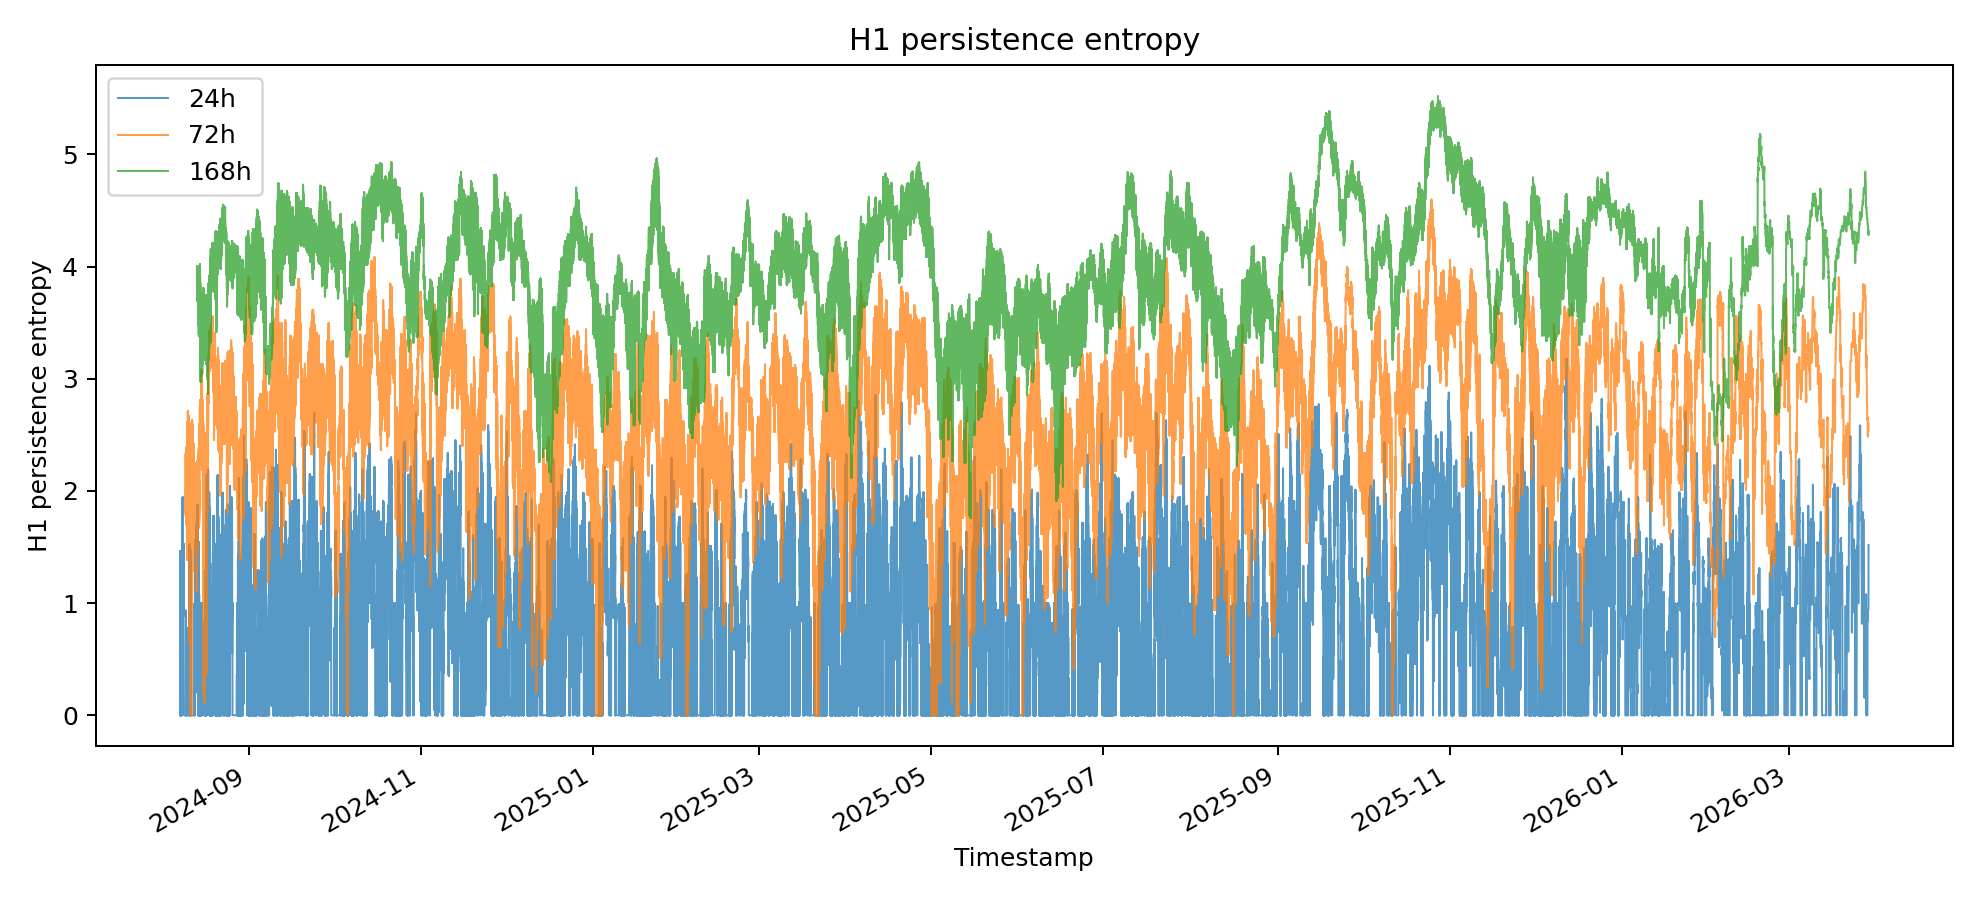

### h1_total_persistence_over_time.png

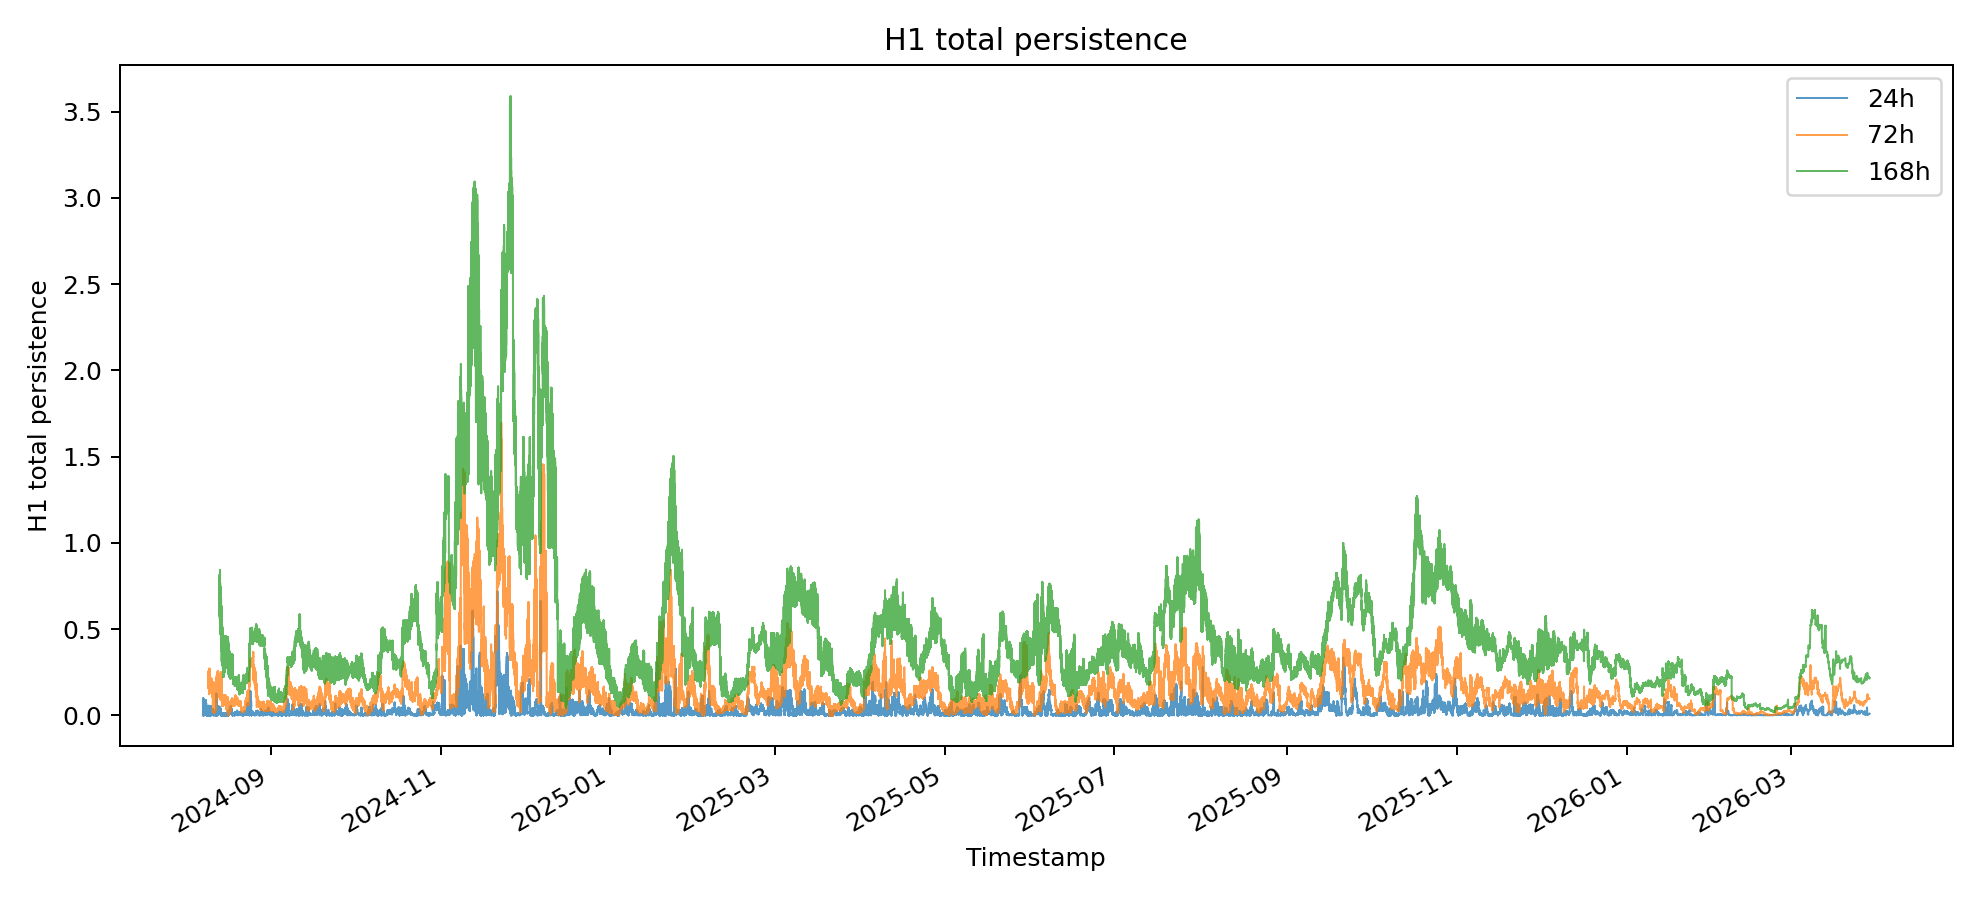

### persistence_diagram_fold1_24h.png

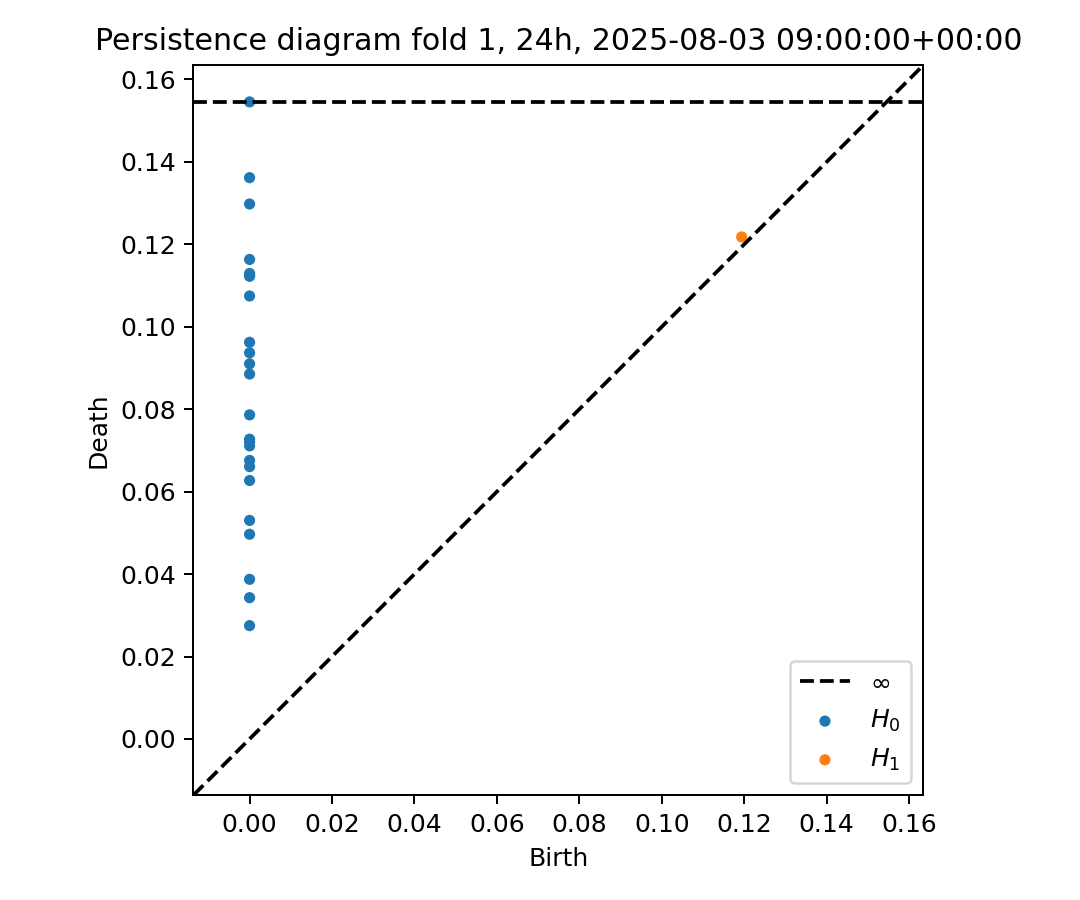

### barcode_fold1_24h.png

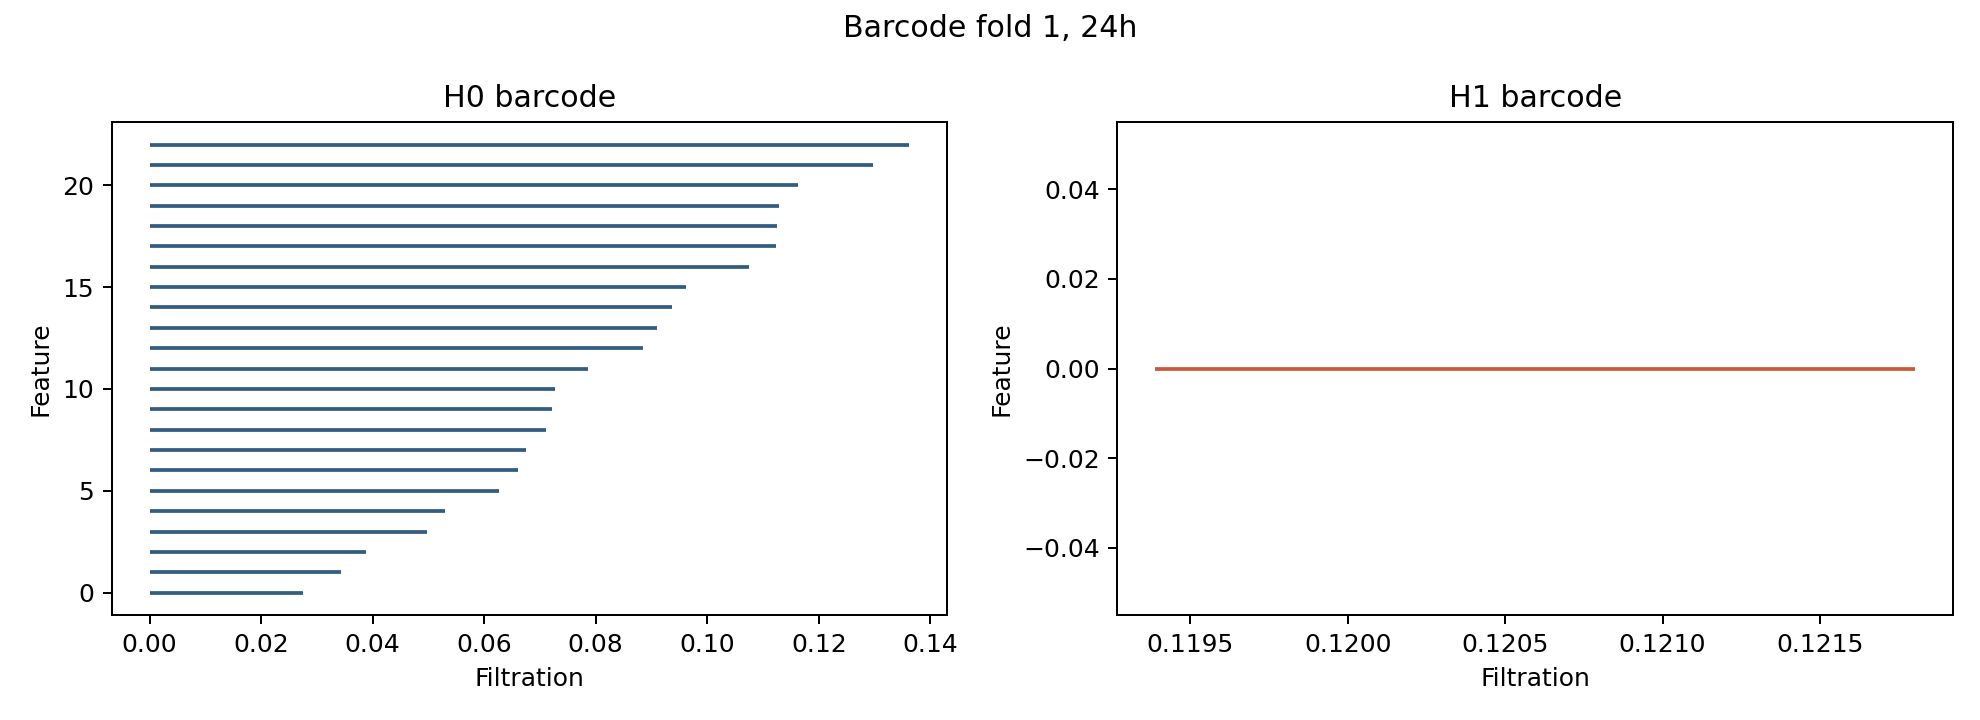

In [8]:
for filename in [
    "h1_entropy_over_time.png",
    "h1_total_persistence_over_time.png",
    "persistence_diagram_fold1_24h.png",
    "barcode_fold1_24h.png",
]:
    path = FIGURES / filename
    if path.exists():
        display(Markdown(f"### {filename}"))
        display(Image(filename=str(path)))